# 06 · 강건성 분석 (심사 보완)

리뷰어 지적(M1~M8)에 대응해, **새 데이터 없이** 결론의 강건성을 점검한다.
- R1 시간/절단: 성숙 코호트에서 사진·설명 효과 재현 (M3)
- R2 PSM 진단: 공변량 균형(SMD) + E-value 민감도 (M1·M2)
- R3 H2 분해 정직화: age 분리 AUC 분해 (M4)
- R4 H3 군집 안정성 + 가격/카테고리 통제 후 archetype 효과 (M5)
- R5 P4 디바이어싱: 인기브랜드 제외 매칭가능성 (M6)
- R6 무판매 셀러 프로파일: 분투 vs 방치 (M8)

In [1]:
import json, sys
from pathlib import Path
import numpy as np, pandas as pd
import statsmodels.api as sm
import matplotlib, matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from xgboost import XGBClassifier

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
matplotlib.rcParams["font.family"] = "AppleGothic"; matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
FIG = ROOT / "results" / "figures"; CACHE = ROOT / "data" / "cache"

lst = pd.read_parquet(CACHE / "features_listing.parquet")
lst["rel_price_missing"] = lst["relative_price_z"].isna().astype(int)
for c in ["relative_price_z"]:
    lst[c] = lst[c].fillna(0.0)
KW = ["kw_measure","kw_flaw","kw_material","kw_purchase","kw_usage","kw_wash"]
lst["condition"] = lst["condition"].fillna("UNK"); lst["category_l1"] = lst["category_l1"].fillna("UNK")
def z(s): return (s - s.mean())/s.std()
R = {}

## R1 · 시간/절단 강건성 — 성숙 코호트에서도 음의 연관이 유지되나
age_days 365~730일(등록 1~2년 전, 모두 ≥12개월 노출)로 성숙도를 고정.

성숙 코호트 n=39,528 (전체 284,654), sold=0.217

사진수 sell-through%  [전체 vs 코호트]
          full  cohort
n_photos              
≤2        26.4    24.1
3-5       21.9    22.1
6+        18.7    19.5


/Users/ashcircle/Dev/ada/.conda/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



통제 후 OR(per SD)  사진: full 0.945 / cohort 0.984  | 설명: full 0.970 / cohort 0.980


/Users/ashcircle/Dev/ada/.conda/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


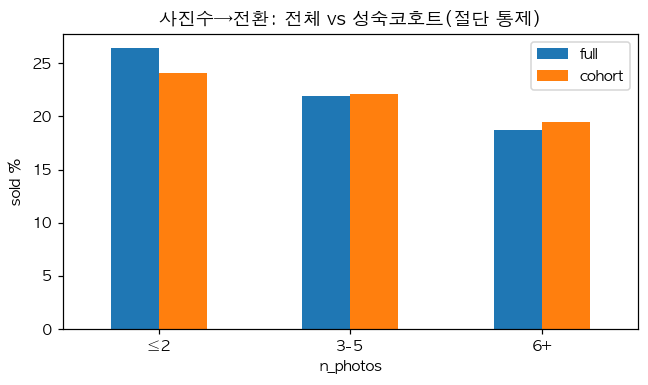

In [2]:
coh = lst[(lst.age_days >= 365) & (lst.age_days <= 730)].copy()
print(f"성숙 코호트 n={len(coh):,} (전체 {len(lst):,}), sold={coh.is_sold.mean():.3f}")

def photo_table(df):
    g = pd.cut(df.n_photos, [-1,2,5,10], labels=["≤2","3-5","6+"])
    return (df.groupby(g, observed=True).is_sold.mean()*100).round(1)
print("\n사진수 sell-through%  [전체 vs 코호트]")
comp = pd.DataFrame({"full": photo_table(lst), "cohort": photo_table(coh)})
print(comp.to_string())

# 코호트 로지스틱 (통제 포함) — 사진/설명 OR
def fit_or(df):
    # H1(01_h1_causal)과 동일 스펙: kw 플래그 + rel_price_missing 포함
    base = pd.DataFrame({"z_photos": z(df.n_photos), "z_desc": z(df.desc_len),
                  "z_logp": z(df.log_price), "z_relp": z(df.relative_price_z),
                  "rel_price_missing": df.rel_price_missing, "z_age": z(df.age_days)})
    for k in KW:
        base[k] = df[k]
    X = pd.concat([base,
        pd.get_dummies(df.brand_top, prefix="b", drop_first=True),
        pd.get_dummies(df.category_l1, prefix="c", drop_first=True),
        pd.get_dummies(df.condition, prefix="cond", drop_first=True),
    ], axis=1).astype(float)
    m = sm.Logit(df.is_sold.values, sm.add_constant(X)).fit(disp=0, method="lbfgs", maxiter=300)
    return np.exp(m.params["z_photos"]), np.exp(m.params["z_desc"])
or_full = fit_or(lst); or_coh = fit_or(coh)
print(f"\n통제 후 OR(per SD)  사진: full {or_full[0]:.3f} / cohort {or_coh[0]:.3f}"
      f"  | 설명: full {or_full[1]:.3f} / cohort {or_coh[1]:.3f}")
R["R1_cohort"] = {"n": int(len(coh)), "sold_rate": round(float(coh.is_sold.mean()),3),
    "photo_sellthrough": {"full": photo_table(lst).to_dict(), "cohort": photo_table(coh).to_dict()},
    "photo_OR": {"full": round(float(or_full[0]),3), "cohort": round(float(or_coh[0]),3)},
    "desc_OR": {"full": round(float(or_full[1]),3), "cohort": round(float(or_coh[1]),3)}}

fig, ax = plt.subplots(figsize=(6,3.6)); comp.plot(kind="bar", ax=ax, rot=0)
ax.set(title="사진수→전환: 전체 vs 성숙코호트(절단 통제)", ylabel="sold %"); fig.tight_layout()
fig.savefig(FIG/"r1_cohort.png", bbox_inches="tight"); plt.show()

## R2 · PSM 진단 — 공변량 균형(SMD) + E-value 민감도

In [3]:
lst["compliant"] = ((lst.n_photos>=3)&(lst.desc_len>=150)).astype(int)
cov = pd.concat([
    pd.DataFrame({"z_logp": z(lst.log_price), "z_age": z(lst.age_days), "z_relp": z(lst.relative_price_z)}),
    pd.get_dummies(lst.brand_top, prefix="b", drop_first=True),
    pd.get_dummies(lst.category_l1, prefix="c", drop_first=True),
    pd.get_dummies(lst.condition, prefix="cond", drop_first=True)], axis=1).astype(float)
t = lst.compliant.values; y = lst.is_sold.values
ps = LogisticRegression(max_iter=1000).fit(StandardScaler().fit_transform(cov), t).predict_proba(
    StandardScaler().fit_transform(cov))[:,1]
tr = np.where(t==1)[0]; ct = np.where(t==0)[0]
nn = NearestNeighbors(n_neighbors=1).fit(ps[ct].reshape(-1,1))
dist, idx = nn.kneighbors(ps[tr].reshape(-1,1)); cal = 0.01
keep = dist.ravel()<=cal
m_tr = tr[keep]; m_ct = ct[idx.ravel()[keep]]

def smd(col):
    a, b = cov[col].values[m_tr], cov[col].values[m_ct]
    a0, b0 = cov[col].values[tr], cov[col].values[ct]
    sd = np.sqrt((cov[col].values[tr].var()+cov[col].values[ct].var())/2) or 1
    return abs(a0.mean()-b0.mean())/sd, abs(a.mean()-b.mean())/sd
key = ["z_logp","z_age","z_relp"]
smd_pre = {c: round(smd(c)[0],3) for c in key}; smd_post = {c: round(smd(c)[1],3) for c in key}
att = y[m_tr].mean()-y[m_ct].mean(); rr = y[m_tr].mean()/y[m_ct].mean()
inv = 1/rr; evalue = inv + np.sqrt(inv*(inv-1))
print(f"매칭률 {keep.mean():.2f} (caliper {cal}) | ATT {att:+.4f} | RR {rr:.3f}")
print(f"SMD(연속공변량) pre {smd_pre} → post {smd_post}")
print(f"E-value {evalue:.2f}  → 미관측 교란이 처치·결과와 각각 RR≥{evalue:.2f}면 효과 소멸")
R["R2_psm"] = {"caliper": cal, "match_rate": round(float(keep.mean()),3), "att": round(float(att),4),
    "rr": round(float(rr),3), "evalue": round(float(evalue),2),
    "smd_pre": smd_pre, "smd_post": smd_post}

매칭률 1.00 (caliper 0.01) | ATT -0.0222 | RR 0.891
SMD(연속공변량) pre {'z_logp': np.float64(0.07), 'z_age': np.float64(0.225), 'z_relp': np.float64(0.123)} → post {'z_logp': np.float64(0.015), 'z_age': np.float64(0.021), 'z_relp': np.float64(0.01)}
E-value 1.49  → 미관측 교란이 처치·결과와 각각 RR≥1.49면 효과 소멸


## R3 · H2 분해 정직화 — age(시간 아티팩트) 분리 AUC 분해

AUC 분해 (age 분리):
  controllable   0.6237
  item(no age)   0.7653
  age_only       0.5302
  item+age       0.7668
  full           0.7863


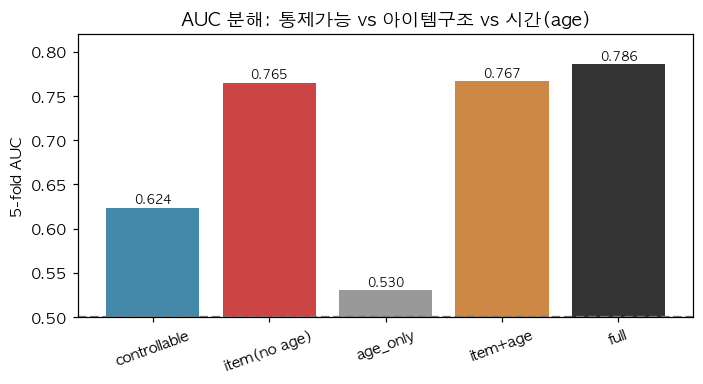

In [4]:
CTRL = ["n_photos","desc_len","n_lines","n_hashtag","n_emoji","kw_measure","kw_flaw","kw_material",
        "kw_purchase","kw_usage","kw_wash","discount_pct","has_discount","relative_price_z"]
def cat_dummies(cols): return pd.concat([pd.get_dummies(lst[c],prefix=c,drop_first=True) for c in cols],axis=1)
top_l2 = lst.category_l2.fillna("UNK").value_counts().head(20).index
lst["category_l2x"] = lst.category_l2.fillna("UNK").where(lst.category_l2.fillna("UNK").isin(top_l2),"OTHER")
STRUCT_ITEM = pd.concat([lst[["log_price"]].astype(float),
    pd.get_dummies(lst.brand_top,prefix="b",drop_first=True),
    pd.get_dummies(lst.category_l1,prefix="c1",drop_first=True),
    pd.get_dummies(lst.category_l2x,prefix="c2",drop_first=True),
    pd.get_dummies(lst.condition,prefix="cond",drop_first=True)], axis=1).astype(float)
AGE = lst[["age_days"]].astype(float)
CTRLX = lst[CTRL].astype(float)

def xgb(): return XGBClassifier(n_estimators=250,max_depth=5,learning_rate=0.1,subsample=0.8,
    colsample_bytree=0.8,tree_method="hist",eval_metric="logloss",n_jobs=-1,random_state=42)
cv = StratifiedKFold(5,shuffle=True,random_state=42)
sets = {"controllable": CTRLX, "item(no age)": STRUCT_ITEM, "age_only": AGE,
        "item+age": pd.concat([STRUCT_ITEM,AGE],axis=1),
        "full": pd.concat([CTRLX,STRUCT_ITEM,AGE],axis=1)}
auc = {k: round(float(cross_val_score(xgb(),X,y,cv=cv,scoring="roc_auc",n_jobs=1).mean()),4) for k,X in sets.items()}
print("AUC 분해 (age 분리):"); [print(f"  {k:14s} {v}") for k,v in auc.items()]
R["R3_auc_decomp"] = auc

fig, ax = plt.subplots(figsize=(6.5,3.6))
ax.bar(list(auc.keys()), list(auc.values()), color=["#48a","#c44","#999","#c84","#333"])
ax.axhline(0.5,ls="--",c="gray"); ax.set(title="AUC 분해: 통제가능 vs 아이템구조 vs 시간(age)", ylabel="5-fold AUC")
ax.set_ylim(0.5,0.82); plt.xticks(rotation=20)
for i,v in enumerate(auc.values()): ax.text(i,v+0.005,f"{v:.3f}",ha="center",fontsize=8)
fig.tight_layout(); fig.savefig(FIG/"r3_auc_decomp.png", bbox_inches="tight"); plt.show()

## R4 · H3 군집 안정성(ARI) + 가격·카테고리 통제 후 archetype 효과

In [5]:
sel = pd.read_parquet(CACHE/"features_seller.parquet")
clusters = pd.read_parquet(CACHE/"seller_clusters.parquet")
FEATS = ["brand_hhi","brand_entropy_norm","share_men","share_new","log_median_price","avg_n_photos"]
selc = sel[sel.n_listings>=5].copy()
Xz = StandardScaler().fit_transform(selc[FEATS].fillna(selc[FEATS].median()))
labs = [KMeans(n_clusters=3,n_init=10,random_state=s).fit_predict(Xz) for s in [0,1,7,42,123]]
aris = [adjusted_rand_score(labs[0],labs[i]) for i in range(1,len(labs))]
print(f"군집 안정성 ARI(seed쌍 평균): {np.mean(aris):.3f}  (1=완전일치)")

# 가격·카테고리·신상품 통제 후 archetype 효과
sb = selc.merge(clusters, on="seller_id", how="inner")
spec = sb.groupby("archetype").brand_hhi.mean().idxmax()  # 전문가형 = HHI 최대
print(f"전문가형(brand_hhi 최대) archetype = {spec}")
ml = lst.merge(clusters, on="seller_id", how="inner")
Xa = pd.concat([pd.get_dummies(ml.archetype, prefix="arch", drop_first=False).drop(columns=[f"arch_{ml.archetype.mode()[0]}"]),
    pd.DataFrame({"z_logp": z(ml.log_price), "z_age": z(ml.age_days)}),
    pd.get_dummies(ml.category_l1,prefix="c",drop_first=True),
    pd.get_dummies(ml.condition,prefix="cond",drop_first=True)], axis=1).astype(float)
ma = sm.Logit(ml.is_sold.values, sm.add_constant(Xa)).fit(disp=0, method="lbfgs", maxiter=300)
spec_col = f"arch_{spec}"
spec_or = float(np.exp(ma.params[spec_col])) if spec_col in ma.params else None
spec_p = float(ma.pvalues[spec_col]) if spec_col in ma.params else None
print(f"가격·카테고리·컨디션·age 통제 후 전문가형 OR={spec_or:.3f}, p={spec_p:.4f}"
      if spec_or else "전문가형이 기준범주로 흡수됨")
R["R4_cluster"] = {"ari_mean": round(float(np.mean(aris)),3), "specialist_archetype": int(spec),
    "specialist_OR_controlled": round(spec_or,3) if spec_or else None,
    "specialist_p_controlled": round(spec_p,4) if spec_p else None}

군집 안정성 ARI(seed쌍 평균): 1.000  (1=완전일치)
전문가형(brand_hhi 최대) archetype = 2


가격·카테고리·컨디션·age 통제 후 전문가형 OR=0.518, p=0.0000


## R5 · P4 디바이어싱 — 인기 브랜드 제외 시 매칭가능성

In [6]:
import sqlite3
with sqlite3.connect(ROOT/"data"/"fruitsfamily.db") as conn:
    wl = pd.read_sql_query("SELECT owner_seller_id, product_id FROM wishlist", conn)
brand_of = lst.set_index("product_id").brand
wl["brand"] = wl.product_id.map(brand_of); wlm = wl.dropna(subset=["brand"])
demand = wlm.groupby("brand").owner_seller_id.nunique()
top10 = demand.sort_values(ascending=False).head(10).index
dead = lst[(lst.is_sold==0)&(lst.age_days>=90)].copy()
dead["dem"] = dead.brand.map(demand).fillna(0)
dead["dem_ex"] = dead.brand.map(demand.drop(top10)).fillna(0)
base_ge1 = (dead.dem>=1).mean(); ex_ge1 = (dead.dem_ex>=1).mean()
print(f"매칭가능(≥1 wisher): 전체 {base_ge1:.1%} → 상위10브랜드 제외 {ex_ge1:.1%}")
print(f"브랜드매핑된 위시 비율: {len(wlm)/len(wl):.1%} (나머지는 listing 외 매물)")
R["R5_p4"] = {"matchable_ge1_all": round(float(base_ge1),3), "matchable_ge1_ex_top10": round(float(ex_ge1),3),
    "median_wishers_ex_top10": float(dead.dem_ex.median()), "brand_mapped_frac": round(len(wlm)/len(wl),3),
    "caveats": "wisher=셀러(구매자 아님); item-level 아닌 brand-level 프록시"}

매칭가능(≥1 wisher): 전체 98.3% → 상위10브랜드 제외 80.0%
브랜드매핑된 위시 비율: 33.8% (나머지는 listing 외 매물)


## R6 · 무판매 셀러 프로파일 — 분투 vs 방치

In [7]:
seller_age = lst.groupby("seller_id").age_days.min().rename("newest_listing_age")  # 가장 최근 매물의 나이
prof = sel.merge(seller_age, on="seller_id", how="left")
zero = prof[prof.n_sold==0]; nonzero = prof[prof.n_sold>0]
print(f"무판매 셀러 {len(zero):,}명")
print(f"  매물수 중앙값: {zero.n_listings.median():.0f} (판매O 셀러 {nonzero.n_listings.median():.0f})")
print(f"  최근매물 나이 중앙값: {zero.newest_listing_age.median():.0f}일 (판매O {nonzero.newest_listing_age.median():.0f}일)")
print(f"  최근매물 >180일(방치 의심) 비율: {(zero.newest_listing_age>180).mean():.1%}")
R["R6_zero_sale"] = {"n": int(len(zero)), "median_listings": float(zero.n_listings.median()),
    "median_newest_age": float(zero.newest_listing_age.median()),
    "pct_stale_180d": round(float((zero.newest_listing_age>180).mean()),3)}

무판매 셀러 1,763명
  매물수 중앙값: 4 (판매O 셀러 37)
  최근매물 나이 중앙값: 46일 (판매O 21일)
  최근매물 >180일(방치 의심) 비율: 16.1%


## 저장

In [8]:
(ROOT/"results"/"robustness.json").write_text(json.dumps(R, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(R, ensure_ascii=False, indent=2))

{
  "R1_cohort": {
    "n": 39528,
    "sold_rate": 0.217,
    "photo_sellthrough": {
      "full": {
        "≤2": 26.4,
        "3-5": 21.9,
        "6+": 18.7
      },
      "cohort": {
        "≤2": 24.1,
        "3-5": 22.1,
        "6+": 19.5
      }
    },
    "photo_OR": {
      "full": 0.945,
      "cohort": 0.984
    },
    "desc_OR": {
      "full": 0.97,
      "cohort": 0.98
    }
  },
  "R2_psm": {
    "caliper": 0.01,
    "match_rate": 1.0,
    "att": -0.0222,
    "rr": 0.891,
    "evalue": 1.49,
    "smd_pre": {
      "z_logp": 0.07,
      "z_age": 0.225,
      "z_relp": 0.123
    },
    "smd_post": {
      "z_logp": 0.015,
      "z_age": 0.021,
      "z_relp": 0.01
    }
  },
  "R3_auc_decomp": {
    "controllable": 0.6237,
    "item(no age)": 0.7653,
    "age_only": 0.5302,
    "item+age": 0.7668,
    "full": 0.7863
  },
  "R4_cluster": {
    "ari_mean": 1.0,
    "specialist_archetype": 2,
    "specialist_OR_controlled": 0.518,
    "specialist_p_controlled": 0.0
  },
 